In [2]:
!pip install matplotlib

55.47s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 3.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 25.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.2/309.2 kB 7.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 37.5 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 27.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 43.9 MB/s eta 0:00:00:00:0100:01


In [1]:
#Visualize data output
import matplotlib.pyplot as plt
import json

In [2]:
#function to visualize
def visual():
    pass

In [20]:
fp = open("./crunched_numbers_compute.json")
op = json.load(fp)
op.keys()

dict_keys(['local_diff_core_latency', 'local_diff_core_throughput', 'remote_nice_same_core_latency', 'remote_nice_same_core_throughput', 'local_nice_same_core_latency', 'local_nice_same_core_throughput', 'local_same_core_latency', 'local_same_core_throughput', 'local_stonewall_latency', 'local_stonewall_throughput', 'remote_diff_core_latency', 'remote_diff_core_throughput', 'remote_same_core_latency', 'remote_same_core_throughput', 'remote_stonewall_latency', 'remote_stonewall_throughput'])

In [4]:
def plot_lat_percentile(experiment):
    data = op[experiment]['latency']['percentile']
    data = {float(k): float(v) for k, v in data.items()}
    y = [i for i in data.keys()]
    x = [data[i] for i in y]
    # Plot CDF
    plt.plot(x, y, label=experiment)
    plt.xlabel("Latency ("+u"\u03bc"+"S)")
    plt.ylabel('ECDF')
    plt.legend(loc="lower right")
    plt.grid(True)

def plot_lat_bar(experiment, name):
    y = op[experiment]['latency']['mean']
    plt.bar([name], [y])
    plt.xlabel("Experiment")
    plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
    plt.grid(True)

def plot_iops_bar(experiment, name):
    y = op[experiment]['iops']['mean']
    y = y / 1000
    plt.bar([name], [y])
    plt.xlabel("Experiment")
    plt.ylabel('KIOPS')
    plt.grid(True)

def plot_bw_bar(experiment, name):
    y = op[experiment]['bw']['mean']
    y = y/1000
    plt.bar([name], [y])
    plt.xlabel("Experiment")
    plt.ylabel('Bandwidth (MBps)')
    plt.grid(True)


Text(0.5, 1.0, 'Local latency CDF')

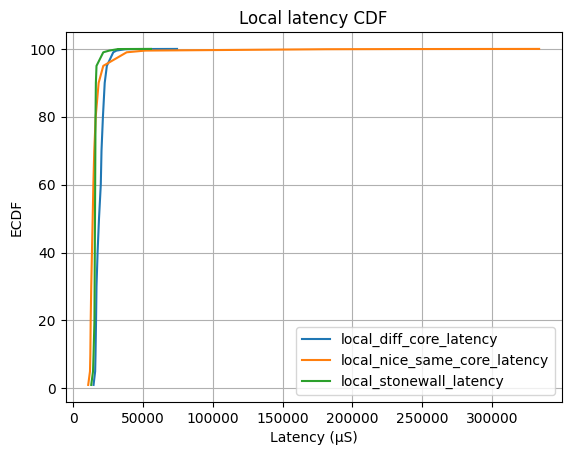

In [18]:
plot_lat_percentile("local_diff_core_latency")
plot_lat_percentile("local_nice_same_core_latency")
#plot_lat_percentile("local_same_core_latency")
plot_lat_percentile("local_stonewall_latency")
plt.title('Local latency CDF')


Text(0.5, 1.0, 'Local latency CDF')

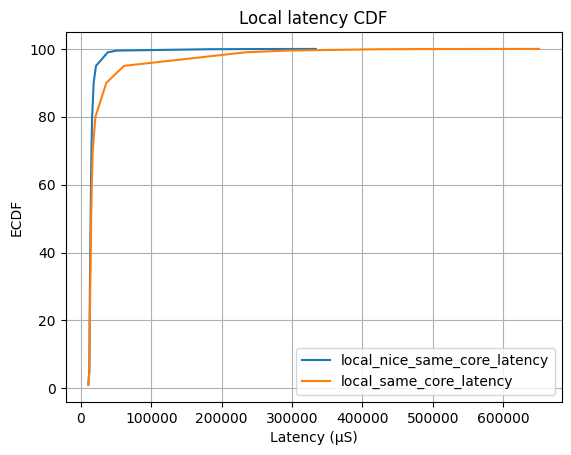

In [12]:
plot_lat_percentile("local_nice_same_core_latency")
plot_lat_percentile("local_same_core_latency")
plt.title('Local latency CDF')

Text(0.5, 1.0, 'Remote latency CDF')

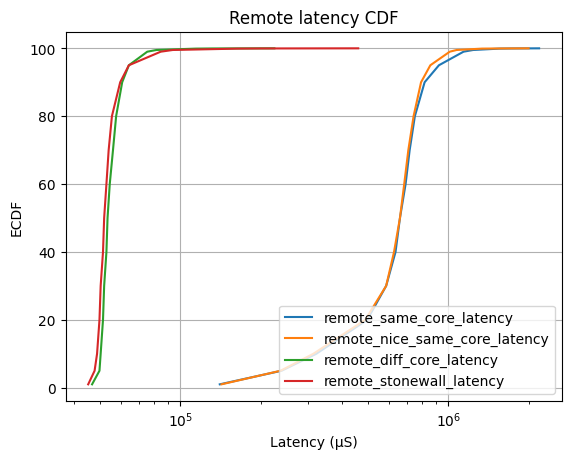

In [21]:
plot_lat_percentile("remote_same_core_latency")
plot_lat_percentile("remote_nice_same_core_latency")
plot_lat_percentile("remote_diff_core_latency")
plot_lat_percentile("remote_stonewall_latency")
plt.xscale("log")
plt.title('Remote latency CDF')

Text(0.5, 1.0, 'Latency bar graph for L-Flow')

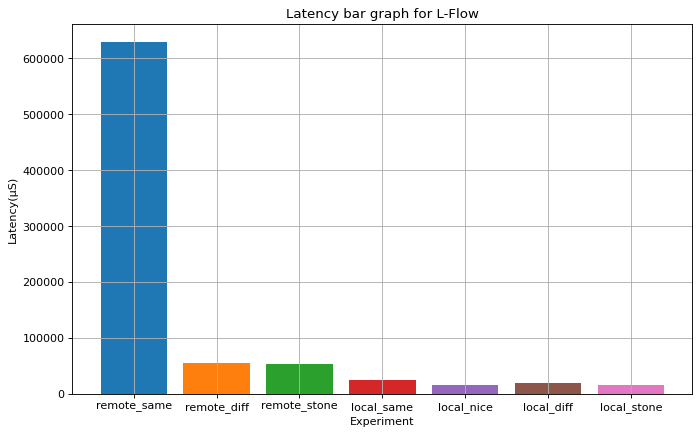

In [15]:
plt.figure(figsize=(10, 6), dpi=80)
plot_lat_bar("remote_same_core_latency","remote_same")
plot_lat_bar("remote_diff_core_latency","remote_diff")
plot_lat_bar("remote_stonewall_latency", "remote_stone")
plot_lat_bar("local_same_core_latency","local_same")
plot_lat_bar("local_nice_same_core_latency","local_nice")
plot_lat_bar("local_diff_core_latency","local_diff")
plot_lat_bar("local_stonewall_latency", "local_stone")
#plt.yscale("log")
plt.title('Latency bar graph for L-Flow')

Text(0.5, 1.0, 'IOPS bar graph for L-Flow')

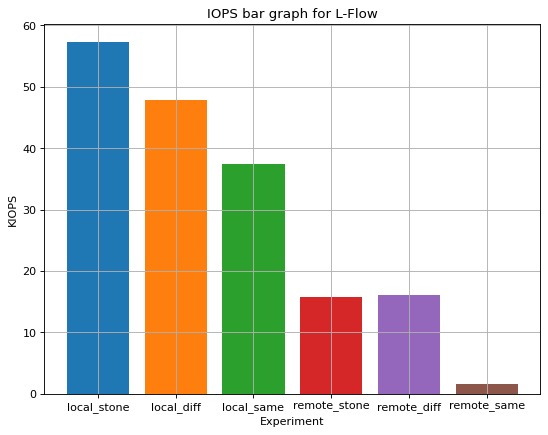

In [8]:
plt.figure(figsize=(8, 6), dpi=80)

plot_iops_bar("local_stonewall_latency","local_stone")
plot_iops_bar("local_diff_core_latency","local_diff")
plot_iops_bar("local_same_core_latency","local_same")

plot_iops_bar("remote_stonewall_latency","remote_stone")
plot_iops_bar("remote_diff_core_latency","remote_diff")
plot_iops_bar("remote_same_core_latency","remote_same")
plt.title('IOPS bar graph for L-Flow')

Text(0.5, 1.0, 'IOPS bar graph for T-Flow')

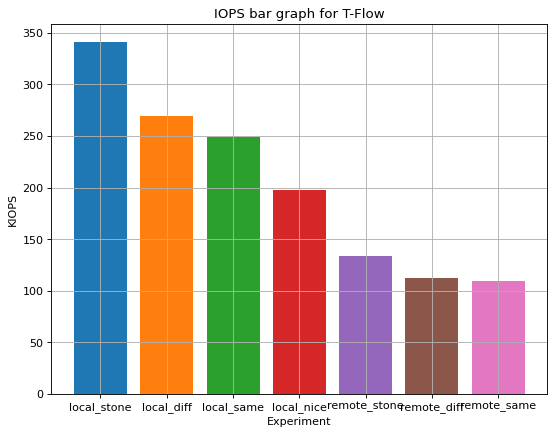

In [14]:
plt.figure(figsize=(8, 6), dpi=80)

plot_iops_bar("local_stonewall_throughput","local_stone")
plot_iops_bar("local_diff_core_throughput","local_diff")
plot_iops_bar("local_same_core_throughput","local_same")
plot_iops_bar("local_nice_same_core_throughput","local_nice")
plot_iops_bar("remote_stonewall_throughput","remote_stone")
plot_iops_bar("remote_diff_core_throughput","remote_diff")
plot_iops_bar("remote_same_core_throughput","remote_same")
plt.title('IOPS bar graph for T-Flow')


KeyError: 'local_RAM_write_QD1_P1'

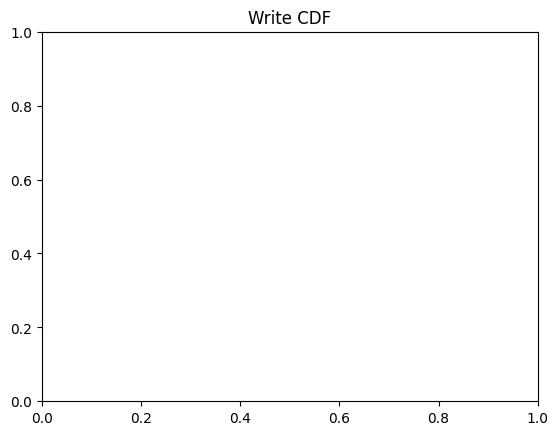

In [10]:
plt.title('Write CDF')
plot_lat_percentile("local_RAM_write_QD1_P1")
plot_lat_percentile("local_SSD_write_QD1_P1")

In [ ]:

device = "SSD"
operation = "write"
plot_lat_bar("local_{}_{}_QD1_P1".format(device, operation), "QD1")
plot_lat_bar("local_{}_{}_QD64_P1".format(device, operation), "QD64")
plot_lat_bar("local_{}_{}_QD128_P1".format(device, operation), "QD128")
plt.yscale("log")

In [ ]:
device = "SSD"
operation = "read"
plot_iops_bar("local_{}_{}_QD1_P1".format(device, operation), "QD1")
plot_iops_bar("local_{}_{}_QD64_P1".format(device, operation), "QD64")
plot_iops_bar("local_{}_{}_QD128_P1".format(device, operation), "QD128")

In [ ]:
device = "SSD"
operation = "read"
plot_bw_bar("local_{}_{}_QD1_P1".format(device, operation), "QD1")
plot_bw_bar("local_{}_{}_QD64_P1".format(device, operation), "QD64")
plot_bw_bar("local_{}_{}_QD128_P1".format(device, operation), "QD128")

In [ ]:
device = "SSD"
operation = "read"
plot_iops_bar("local_{}_{}_QD128_P1".format(device, operation), "P1")
plot_iops_bar("local_{}_{}_QD128_P2".format(device, operation), "P2")
plot_iops_bar("local_{}_{}_QD128_P4".format(device, operation), "P4")

In [ ]:
device = "SSD"
operation = "read"
plot_bw_bar("local_{}_{}_QD128_P1".format(device, operation), "P1")
plot_bw_bar("local_{}_{}_QD128_P2".format(device, operation), "P2")
plot_bw_bar("local_{}_{}_QD128_P4".format(device, operation), "P4")

In [ ]:
fp = open("./")